# Assignment 2 — Model 3: 1D CNN with Pretrained Word2Vec Embeddings

This notebook trains a **1D Convolutional Neural Network** using **pretrained Word2Vec** embeddings.

Key techniques:
- **Gensim Word2Vec** trained on the IMDB corpus (300-dim)
- **Frozen embedding matrix** loaded from Word2Vec weights
- **Parallel multi-kernel CNN** (bigrams, trigrams, 4-grams) — inspired by TextCNN
- **Global max pooling** to extract salient features
- **Batch normalization** + **Dropout** for regularization
- **Adam optimizer** with warm-up + cosine decay

In [1]:
!pip install gensim

     ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
     ---------------------------------------- 0.2/24.4 MB 5.0 MB/s eta 0:00:05
      --------------------------------------- 0.3/24.4 MB 3.5 MB/s eta 0:00:07
      --------------------------------------- 0.6/24.4 MB 3.9 MB/s eta 0:00:07
     - -------------------------------------- 0.9/24.4 MB 4.4 MB/s eta 0:00:06
     - -------------------------------------- 1.2/24.4 MB 4.6 MB/s eta 0:00:06
     -- ------------------------------------- 1.5/24.4 MB 5.1 MB/s eta 0:00:05
     -- ------------------------------------- 1.8/24.4 MB 5.3 MB/s eta 0:00:05
     --- ------------------------------------ 2.2/24.4 MB 5.5 MB/s eta 0:00:05
     ---- ----------------------------------- 2.6/24.4 MB 5.6 MB/s eta 0:00:04
     ---- ----------------------------------- 3.0/24.4 MB 5.7 MB/s eta 0:00:04
     ----- ---------------------------------- 3.5/24.4 MB 6.0 MB/s eta 0:00:04
     ------ --------------------------------- 3.8/24.4 MB 6


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import re, os, json
from bs4 import BeautifulSoup
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import (
    Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout,
    BatchNormalization, Concatenate, Activation
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

from gensim.models import Word2Vec

os.makedirs('results', exist_ok=True)
print(f'TensorFlow: {tf.__version__}')

TensorFlow: 2.21.0


## 1. Data Loading & Preprocessing

In [4]:
df = pd.read_csv('data/IMDB Dataset.csv')
df = df.drop_duplicates().reset_index(drop=True)
print(f'Reviews: {len(df)}')

def clean_text(text):
    text = BeautifulSoup(text, 'html.parser').get_text()
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean'] = df['review'].apply(clean_text)
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

X_raw = df['clean'].values
y = df['label'].values

X_temp, X_test_raw, y_temp, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y)
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

print(f'Train: {len(X_train_raw)}, Val: {len(X_val_raw)}, Test: {len(X_test_raw)}')

Reviews: 49582
Train: 29748, Val: 9917, Test: 9917


## 2. Train Word2Vec Embeddings with Gensim

In [5]:
EMBED_DIM   = 300
VOCAB_SIZE  = 20000
MAX_LEN     = 250

# Word2Vec requires tokenized sentences
print('Tokenizing for Word2Vec training...')
all_sentences = [text.split() for text in X_raw]   # use full dataset

print('Training Word2Vec (this may take 2–5 minutes)...')
w2v_model = Word2Vec(
    sentences=all_sentences,
    vector_size=EMBED_DIM,
    window=5,
    min_count=2,
    workers=4,
    epochs=10,
    sg=1          # Skip-gram
)
w2v_model.save('results/word2vec_imdb.model')
print(f'Word2Vec trained. Vocabulary size: {len(w2v_model.wv)}')

Tokenizing for Word2Vec training...
Training Word2Vec (this may take 2–5 minutes)...
Word2Vec trained. Vocabulary size: 61876


## 3. Build Embedding Matrix

In [6]:
# Fit Keras tokenizer on training data only
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_raw)

def encode(texts):
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_LEN, padding='post', truncating='post')

X_train = encode(X_train_raw)
X_val   = encode(X_val_raw)
X_test  = encode(X_test_raw)

# Build embedding matrix from Word2Vec
word_index = tokenizer.word_index
embedding_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM))
hits, misses = 0, 0

for word, idx in word_index.items():
    if idx >= VOCAB_SIZE:
        continue
    if word in w2v_model.wv:
        embedding_matrix[idx] = w2v_model.wv[word]
        hits += 1
    else:
        # Random init for OOV words
        embedding_matrix[idx] = np.random.normal(0, 0.1, EMBED_DIM)
        misses += 1

print(f'Embedding matrix: {embedding_matrix.shape}')
print(f'Word2Vec hits: {hits} | OOV (random init): {misses}')

Embedding matrix: (20000, 300)
Word2Vec hits: 19998 | OOV (random init): 1


## 4. TextCNN Architecture (Multi-Kernel 1D CNN)

In [7]:
def build_textcnn(vocab_size, embed_dim, max_len, embedding_matrix,
                  num_filters=128, kernel_sizes=(2, 3, 4), dropout_rate=0.5):
    """
    TextCNN: parallel convolutions with different kernel sizes,
    each capturing different n-gram patterns.
    """
    inputs = Input(shape=(max_len,))

    # Pretrained, fine-tunable embedding
    x = Embedding(
        vocab_size, embed_dim,
        weights=[embedding_matrix],
        trainable=True,           # allow fine-tuning
        input_length=max_len
    )(inputs)

    # Parallel conv branches
    branches = []
    for k in kernel_sizes:
        conv = Conv1D(num_filters, k, padding='same')(x)
        conv = BatchNormalization()(conv)
        conv = Activation('relu')(conv)
        pool = GlobalMaxPooling1D()(conv)
        branches.append(pool)

    merged = Concatenate()(branches)          # (num_filters * len(kernel_sizes),)
    out = Dropout(dropout_rate)(merged)
    out = Dense(128, activation='relu')(out)
    out = BatchNormalization()(out)
    out = Dropout(dropout_rate / 2)(out)
    out = Dense(1, activation='sigmoid')(out)

    model = Model(inputs, out)
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_textcnn(VOCAB_SIZE, EMBED_DIM, MAX_LEN, embedding_matrix)
model.summary()

C:\Users\lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 250)               │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding (Embedding)         │ (None, 250, 300)          │       6,000,000 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d (Conv1D)               │ (None, 250, 128)          │          76,928 │ embedding[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_1 (Conv1D)             │ (None, 250, 128)          │         115,328 │ embedding[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_2 (Conv1D)             │ (None, 250, 128)          │         153,728 │ embedding[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization           │ (None, 250, 128)          │             512 │ conv1d[0][0]               │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_1         │ (None, 250, 128)          │             512 │ conv1d_1[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_2         │ (None, 250, 128)          │             512 │ conv1d_2[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation (Activation)       │ (None, 250, 128)          │               0 │ batch_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_1 (Activation)     │ (None, 250, 128)          │               0 │ batch_normalization_1[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_2 (Activation)     │ (None, 250, 128)          │               0 │ batch_normalization_2[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_max_pooling1d          │ (None, 128)               │               0 │ activation[0][0]           │
│ (GlobalMaxPooling1D)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_max_pooling1d_1        │ (None, 128)               │               0 │ activation_1[0][0]         │
│ (GlobalMaxPooling1D)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_max_pooling1d_2        │ (None, 128)               │               0 │ activation_2[0][0]         │
│ (GlobalMaxPooling1D)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 6,397,441 (24.40 MB)

 Trainable params: 6,396,417 (24.40 MB)

 Non-trainable params: 1,024 (4.00 KB)

## 5. Training

In [8]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1),
    ModelCheckpoint('results/best_cnn.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=256,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6020 - loss: 0.7214
Epoch 1: val_accuracy improved from None to 0.84461, saving model to results/best_cnn.keras
117/117 ━━━━━━━━━━━━━━━━━━━━ 238s 2s/step - accuracy: 0.6903 - loss: 0.5895 - val_accuracy: 0.8446 - val_loss: 0.4054 - learning_rate: 0.0010
Epoch 2/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8334 - loss: 0.3802
Epoch 2: val_accuracy improved from 0.84461 to 0.87002, saving model to results/best_cnn.keras
117/117 ━━━━━━━━━━━━━━━━━━━━ 256s 2s/step - accuracy: 0.8368 - loss: 0.3748 - val_accuracy: 0.8700 - val_loss: 0.3182 - learning_rate: 0.0010
Epoch 3/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8629 - loss: 0.3160
Epoch 3: val_accuracy improved from 0.87002 to 0.88010, saving model to results/best_cnn.keras
117/117 ━━━━━━━━━━━━━━━━━━━━ 223s 2s/step - accuracy: 0.8698 - loss: 0.3067 - val_accuracy: 0.8801 - val_loss: 0.2794 - learning_rate: 0.0010
Epoch 4/20
117/117 ━━━━━━━━━━━━━━━━━━

## 6. Evaluation

310/310 ━━━━━━━━━━━━━━━━━━━━ 16s 49ms/step
TEST SET EVALUATION — 1D CNN + Word2Vec
Test Loss:     0.2607
Test Accuracy: 0.8965 (89.65%)

Classification Report:
              precision    recall  f1-score   support

    Negative       0.92      0.87      0.89      4940
    Positive       0.88      0.92      0.90      4977

    accuracy                           0.90      9917
   macro avg       0.90      0.90      0.90      9917
weighted avg       0.90      0.90      0.90      9917



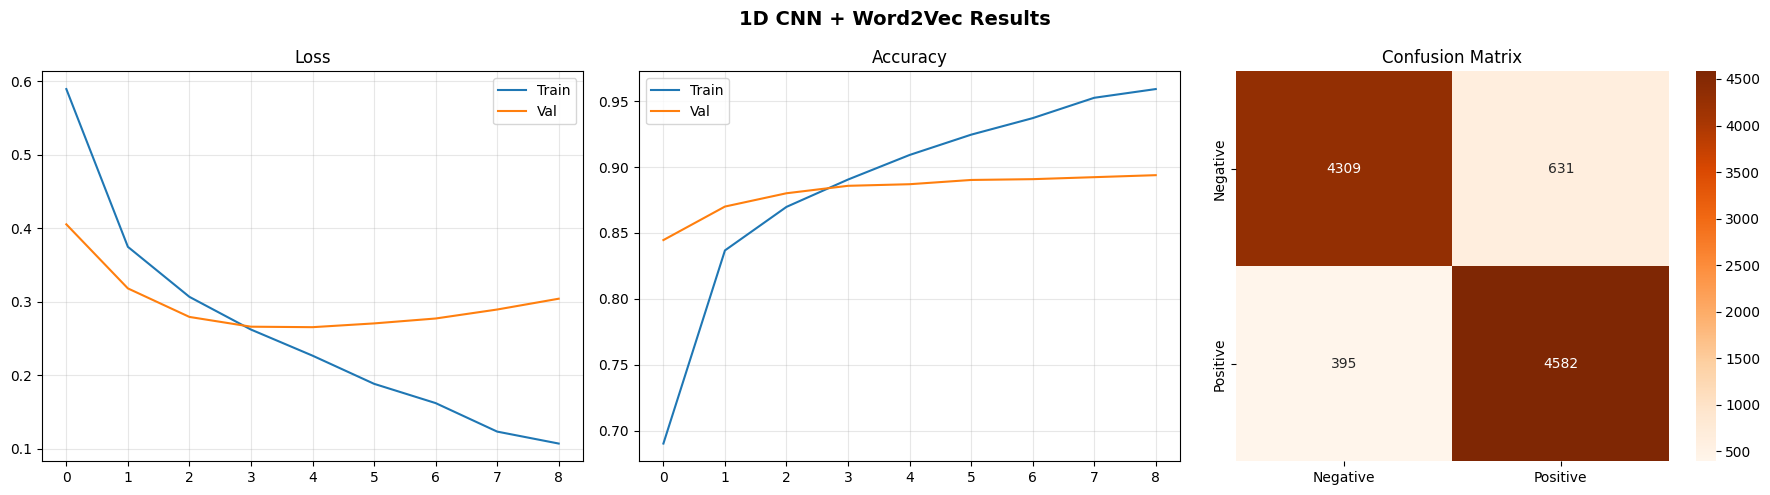

In [9]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob >= 0.5).astype(int).flatten()

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
cm     = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=['Negative', 'Positive'])

print('=' * 60)
print('TEST SET EVALUATION — 1D CNN + Word2Vec')
print('=' * 60)
print(f'Test Loss:     {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'\nClassification Report:\n{report}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['accuracy'], label='Train')
axes[1].plot(history.history['val_accuracy'], label='Val')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes[2],
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
axes[2].set_title('Confusion Matrix')

plt.suptitle('1D CNN + Word2Vec Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/model3_plots.png', dpi=150)
plt.show()

## 7. Save Results

In [10]:
tn, fp, fn, tp = cm.ravel()
precision = tp / (tp + fp)
recall    = tp / (tp + fn)
f1        = 2 * precision * recall / (precision + recall)

results = {
    'model': '1D CNN with Pretrained Word2Vec',
    'architecture': 'Embedding(W2V,300) -> [Conv1D(128,k)+BN+ReLU+GlobalMaxPool for k in {2,3,4}] -> Concat -> Dropout(0.5) -> Dense(128) -> Dense(1)',
    'word2vec': f'Skip-gram, dim={EMBED_DIM}, window=5, min_count=2, epochs=10',
    'vocab_size': VOCAB_SIZE,
    'max_sequence_len': MAX_LEN,
    'embedding_dim': EMBED_DIM,
    'optimizer': 'Adam (lr=1e-3, ReduceLROnPlateau)',
    'test_loss': round(float(test_loss), 4),
    'test_accuracy': round(float(test_acc), 4),
    'precision': round(precision, 4),
    'recall': round(recall, 4),
    'f1_score': round(f1, 4),
    'epochs_trained': len(history.history['loss'])
}

with open('results/results_model3.json', 'w') as f:
    json.dump(results, f, indent=2)

with open('results/results_model3.txt', 'w') as f:
    f.write('MODEL 3: 1D CNN + WORD2VEC — RESULTS\n')
    f.write('=' * 60 + '\n\n')
    for k, v in results.items():
        f.write(f'{k:<40}: {v}\n')
    f.write('\nConfusion Matrix:\n')
    f.write(f'  TN={tn}  FP={fp}\n  FN={fn}  TP={tp}\n')
    f.write('\nClassification Report:\n')
    f.write(report)

print('Results saved.')
for k, v in results.items():
    print(f'  {k:<40}: {v}')

Results saved.
  model                                   : 1D CNN with Pretrained Word2Vec
  architecture                            : Embedding(W2V,300) -> [Conv1D(128,k)+BN+ReLU+GlobalMaxPool for k in {2,3,4}] -> Concat -> Dropout(0.5) -> Dense(128) -> Dense(1)
  word2vec                                : Skip-gram, dim=300, window=5, min_count=2, epochs=10
  vocab_size                              : 20000
  max_sequence_len                        : 250
  embedding_dim                           : 300
  optimizer                               : Adam (lr=1e-3, ReduceLROnPlateau)
  test_loss                               : 0.2607
  test_accuracy                           : 0.8965
  precision                               : 0.879
  recall                                  : 0.9206
  f1_score                                : 0.8993
  epochs_trained                          : 9
